In [5]:
import itertools
import copy

import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib
import argparse

import time
%matplotlib inline

In [6]:
def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    function taken from
    https://stackoverflow.com/questions/7404116/...
        ...defining-the-midpoint-of-a-colormap-in-matplotlib
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower ofset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax/(vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highets point in the colormap's range.
          Defaults to 1.0 (no upper ofset). Should be between
          `midpoint` and 1.0.
    '''
    cdict = {  'red': [],  'green': [], 'blue': [],  'alpha': []  }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    plt.register_cmap(cmap=newcmap)

    return newcmap

In [7]:
def value_iteration(prior_mean, prior_std, bins, raw_bins, args, options='estimate'):  
    converge = 0
    
    c1 = args['c1']; c2 = args['c2']; c3 = args['c3']

    gamma = args['gamma']
    sigma0 = args['sigma0']
    Sigma1 = args['Sigma1']
    l_0 = args['l_0']
    threshold = args['threshold'] if options == 'estimate' else 1e-12
    
    S_square = args['S']**2
    value = np.zeros((args['K'], S_square))
    pi = np.zeros((args['K'], S_square))
    
    # Generate middle of the bins as representation of state
    new_bins_2d = []
    raw_new_bins = []
    flag = []
    
    for k in range(args['K']):
        raw_bins_k = raw_bins[k]
        
        new_bins_state_1 = copy.deepcopy(raw_bins_k[0])
        new_bins_state_2 = copy.deepcopy(raw_bins_k[1])

        state_1_space = np.diff(raw_bins_k[0])[0] 
        state_2_space = np.diff(raw_bins_k[1])[0]

        new_bins_state_1[1:] = raw_bins_k[0][1:] - state_1_space/ 2
        new_bins_state_1 = np.append(new_bins_state_1, args['s1_limit'])

        new_bins_state_2[1:] = raw_bins_k[1][1:] - state_2_space / 2
        new_bins_state_2 = np.append(new_bins_state_2, args['s1_limit'] * (k+1))
        
        new_bins_2d_k = np.stack(list(itertools.product(new_bins_state_1, new_bins_state_2)))
        raw_new_bins_k = (new_bins_state_1, new_bins_state_2)
        
        # Append middle of the bins
        new_bins_2d.append(new_bins_2d_k)
        raw_new_bins.append(raw_new_bins_k)
        
        # Flag some spaces to white
        flag_k = new_bins_2d_k[:, 1] <= new_bins_2d_k[:, 0] * (k+1)
        flag.append(flag_k)
    
    new_bins_2d = np.stack(new_bins_2d)
    raw_new_bins = np.stack(raw_new_bins)
    
    trans_prob_start_time = time.time()
    
    # Pre calculate transition probability to avoid repetition when doing value iteration 
    if options == 'estimate':
        prob = calc_transition_prob(new_bins_2d, raw_new_bins, bins, prior_mean, prior_std, args)
    elif options == 'optimal':
        prob = calc_optimal_transition_prob(new_bins_2d, raw_new_bins, bins, prior_mean, args)
    prob = np.abs(prob)
    
    trans_prob_end_time = time.time()
    
    # Time how long the VI runs
    start = time.time()
   
    lk_matrix = copy.deepcopy(new_bins_2d[:, :, 0])
    
    for i in range(args['max_iter']):
        old_value = copy.deepcopy(value)
        
        # Set value on the edge
        value[args['K']-1] = np.where(lk_matrix[args['K']-1] <= args['r_limit'], c3, c1)
        pi[args['K']-1] = np.where(lk_matrix[args['K']-1] <= args['r_limit'], 0, 1)

        cost_A0 = copy.deepcopy(value[:-1, :]) # Cost of "not" replacing machines (matrix K x S)
        for k in range(args['K']-1):
            future_cost_k = c3 + gamma * value[k+1, :]
            cost_A0[k, :] = prob[k,:,:] @ future_cost_k.T
        cost_A1 = c2 + gamma * value[0, 0] # Cost of replacing machine (scalar)

        # Set value and pi
        value[:-1, :] = np.where(cost_A0 >= cost_A1, cost_A0, cost_A1)
        pi[:-1, :] = np.where(cost_A0 >= cost_A1, 0, 1)

        # Reset value and pi if lk exceeds threshold
        value = np.where(lk_matrix > args['r_limit'], c1 + gamma * value[0, 0], value)
        pi = np.where(lk_matrix > args['r_limit'], 1, pi)
            
#         if i % 200 == 0:
#         print(f"Iter {i+1}: gap = {np.linalg.norm(old_value - value)}")
        if np.linalg.norm(old_value - value) < threshold:
            converge = 1
            break 
    if converge == 0:
        print("Reach maximum iteration before convergent")
        
    end = time.time()
    elapsed = end - start
    elapsed_prob = trans_prob_end_time - trans_prob_start_time

    print(f"VI took {elapsed // 60:.4f} mins {elapsed % 60:.4f} seconds | calc. prob took {elapsed_prob // 60:.4f} mins {elapsed_prob % 60:.4f} seconds")
    
    # Prevent signed zero
    pi = np.abs(pi); value = np.abs(value)
    return value, pi, prob, flag

In [64]:
def discretize_states(lk_list, args):
    bins = np.linspace(args['theta'], args['s_limit'], args['S']-1)
    discrete_state_space = np.digitize(lk_list, bins, right=False)
    return discrete_state_space, bins

def calc_one_step_transition_prob(mean, std, lk, bins, delta, sigma):
    # Calculate mean and std for l_{k+1}
    mean_lk1 = lk + mean * delta
    std_lk1 = np.sqrt(std**2 * delta**2 + sigma**2)

    # Derive cdf of max of each bin
    normalized_bins = (bins - mean_lk1) / std_lk1
    cdf_bins = scipy.stats.norm.cdf(normalized_bins)
    
    prob = np.diff(cdf_bins)
    prob = np.insert(prob, 0, cdf_bins[0]) # Add prob for lk <= 0
    prob = np.append(prob, 1 - cdf_bins[-1])
    return prob

def calc_transition_prob(state_partition, bins, prior_mean, prior_std, args):
    # Matrix of K x S x Sw
    prob = np.zeros((args['K'], args['S'], args['S']))
    for k in range(args['K']):
        for s in range(args['S']):
            tk = args['delta'] * k
            lk = state_partition[s]
            # Update posterior distribution by approximated lk if k > 0
            if k > 0:
                a = ((tk**2) / (tk**2*args['sigma1']**2 + k*args['sigma']**2)) + (1/(prior_std**2))
                b = (((lk - args['theta']) * tk) / (tk**2*args['sigma1']**2 + k*args['sigma']**2)) + (prior_mean/(prior_std**2))

                mu_k = b/a
                sigma_k = np.sqrt(1/a)
                print(f"At state {s} | mu = {mu_k}, sigma = {sigma_k}")
            else:
                mu_k = prior_mean
                sigma_k = prior_std
        
            prob[k, s, :] = calc_one_step_transition_prob(mu_k, sigma_k, lk, bins, args['delta'], args['sigma'])
    
    return prob

def calc_cost(k, args, cost_type):
    replace_cost = args['c1'] if cost_type == 'urgent' else args['c2']
    if args["gamma"] == 1:
        cost = k * args["c3"] + replace_cost
    else:
        cost = args["c3"]*(1-args["gamma"]**(k+1))/(1-args["gamma"]) + replace_cost*args["gamma"]**k    
    return cost

def get_prior(args, experiment):
    
    # Initialize variables
    N = args['N']
    d = args['d']
    
    # Construct linear and quadratic matrix/vector
    if experiment == 'collaborative':
        B0 = np.zeros(((N+1)*d, 1))
        B0[:d] = args['mu3'] / args['Sigma3']**2

        A0 = np.zeros(((N+1)*d, (N+1)*d))
        A0[:d, :d] = N / args['Sigma2']**2 + 1 / args['Sigma3']**2

        for i in range(args['N']):
            A0[:d, (i+1)*d:(i+2)*d] = - 1 / args['Sigma2']**2
            A0[(i+1)*d:(i+2)*d, :d] = - 1 / args['Sigma2']**2
            A0[(i+1)*d:(i+2)*d, (i+1)*d:(i+2)*d] = 1 / args['Sigma2']**2

        mu0_mean = np.linalg.solve(A0, B0)    
        mu0_cov = np.linalg.inv(A0)
        
    elif experiment == 'isolated' or experiment == 'EP':
        mu0_mean = np.kron(np.ones((N+1, 1)), args['mu3'])
        mu0_cov = np.kron(np.eye(N+1) ,args['Sigma3']+args['Sigma2'])

    mu0_std = np.sqrt(np.diag(mu0_cov))
    return mu0_mean, mu0_std

def update_posterior(diff_lk_list, args, noise_sigma=None):
    '''
    diff_lk_list (list) - list of transition at timestep k minus transition at timestep k-1
    args (dict) - dict containing parameters
    t (int) - timestep at which the posterior is updated.
    '''
    d = args['d']
    N = args['N']
    
    ##### Initialize A #####
    # Inverse of Sigma1, Sigma2, and Sigma 3 are going to be used a lot
    Sigma1_inv, Sigma2_inv, Sigma3_inv = np.linalg.inv(args['Sigma1']), np.linalg.inv(args['Sigma2']), np.linalg.inv(args['Sigma3'])
    
    mu1_block_A = np.zeros((N*d, N*d))
    mu1_block_B = np.zeros((N*d, 1))
    
    sum_m = 0
    for n in range(N):
        mu1_block_A[n*d:(n+1)*d, n*d:(n+1)*d] = Sigma2_inv
        diff_lk_n = list(itertools.chain.from_iterable(diff_lk_list[n]))
        for k, diff_lk in diff_lk_n:
            tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(d)).reshape(-1, 1)
            tt_k_matrix = tt_k @ tt_k.T
            denom = (args['sigma0']**2 + tt_k.T @ args['Sigma1'] @ tt_k).item()

            mu1_block_A[n*d: (n+1)*d, n*d:(n+1)*d] += tt_k_matrix / denom
            mu1_block_B[n*d: (n+1)*d] += (diff_lk * tt_k) / denom
        
        # Add noise
        laplacian_noise = 0 if noise_sigma is None else np.random.laplace(scale=noise_sigma)
        mu1_block_B[n*d: (n+1)*d] += laplacian_noise

    # Construct all blocks    
    mu1_mu2_block = np.kron(np.ones((N, 1)), -Sigma2_inv)
    mu2_block_A = N * Sigma2_inv + Sigma3_inv
    mu2_block_B = Sigma3_inv @ args['mu3']
     
    # Construct matrix A
    quadratic_matrix = np.block([[mu2_block_A,      mu1_mu2_block.T],
                                [mu1_mu2_block,     mu1_block_A]])
    linear_matrix = np.block([[mu2_block_B],
                              [mu1_block_B]])
    
#     # Solve for posterior
    post_mean = np.linalg.solve(quadratic_matrix, linear_matrix)
    post_cov = np.linalg.inv(quadratic_matrix)
    
    return post_mean, post_cov

def update_isolated_posterior(diff_lk_list, args):
    d = args['d']
    N = args['N']
    mu0_mean = np.zeros(((N+1)*d, 1))
    mu0_cov = np.zeros(((N+1)*d, (N+1)*d))
    
    for n in range(args['N']):
        diff_lk_n = list(itertools.chain.from_iterable(diff_lk_list[n]))
        if args['Sigma1'].ndim == 1:
            A = 1 / (args['Sigma2'] + args['Sigma3'])
            B = args['mu3'] / (args['Sigma2'] + args['Sigma3'])
            
            A = A.reshape(-1, 1); B = B.reshape(-1, 1)
        else:     
            A = np.linalg.inv(args['Sigma2'] + args['Sigma3'])
            B = np.linalg.inv(args['Sigma2'] + args['Sigma3']) @ args['mu3']
        
        for k, diff_lk in diff_lk_n:
            tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(d)).reshape(-1, 1)
            tt_k_matrix = tt_k @ tt_k.T
            denom = (args['sigma0']**2 + tt_k.T @ args['Sigma1'] @ tt_k).item()   
            
            A += tt_k_matrix / denom
            B += diff_lk * tt_k / denom

        mu0_mean[(n+1)*d:(n+2)*d] = np.linalg.solve(A, B)
        mu0_cov[(n+1)*d:(n+2)*d, (n+1)*d:(n+2)*d] = np.linalg.inv(A)

    return mu0_mean.flatten(), mu0_cov

def update_EP_posterior(r_list, Q_list, r0, Q0, diff_lk_list, args):
    N = args['N']
    d = args['d']
    # Device-side
    r_delta = 0
    Q_delta = 0

    r_list_new = np.zeros((N, d))
    Q_list_new = np.zeros((N, d, d))
    for i in range(args['N']):
        # Subtract old r from r0 and old Q from Q0 to remove the impact of old params
        r_cavity = copy.deepcopy(r0 - r_list[i].reshape(-1, 1)) 
        Q_cavity = copy.deepcopy(Q0 - Q_list[i])
        
        # Initialize linear shift and precision mat of tilted dist.
        r_hybrid = copy.deepcopy(r_cavity); Q_hybrid = copy.deepcopy(Q_cavity)
        
        diff_lk_n = list(itertools.chain.from_iterable(diff_lk_list[i]))
        # Compute f_k(mu_2)
        for k, diff_lk in diff_lk_n:
            tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(d)).reshape(-1, 1)
            tt_k_matrix = tt_k @ tt_k.T
            denom = (args['sigma0']**2 + tt_k.T @ (args['Sigma1'] + args['Sigma2']) @ tt_k).item()    

            r_hybrid += diff_lk * tt_k / denom
            Q_hybrid += tt_k_matrix / denom

        # Update the contribution to the central prior
        r_delta += r_hybrid - r0
        Q_delta += Q_hybrid - Q0
        
        # Append new r_list and Q_list (local approximation)
        r_list_new[i, :] = (r_hybrid - r_cavity).flatten()
        Q_list_new[i, :, :] = Q_hybrid - Q_cavity

    # Update global approximation
    r0_new = r0 + r_delta
    Q0_new = Q0 + Q_delta

    return r0_new, Q0_new, r_list_new, Q_list_new

def device_posterior_update(r0, Q0, r_list, Q_list, diff_lk_list, args):
    d = args['d']
    N = args['N']
    mu0_mean = np.zeros(((N+1)*d, 1))
    mu0_cov = np.zeros(((N+1)*d, (N+1)*d))

    Sigma1_inv, Sigma2_inv, Sigma3_inv = np.linalg.inv(args['Sigma1']), np.linalg.inv(args['Sigma2']), np.linalg.inv(args['Sigma3'])

    for i in range(args['N']):
        # (Implicitly) calc mean and variance of q_sub_i(mu_2)
        r_sub_i = copy.deepcopy(r0 - r_list[i].reshape(-1, 1))
        Q_sub_i = copy.deepcopy(Q0 - Q_list[i])
        Q_sub_i_inv = np.linalg.inv(Q_sub_i)
        
        mu1_i_cov_inv = np.linalg.inv(Q_sub_i_inv + args['Sigma2'])
        
        A = copy.deepcopy(mu1_i_cov_inv)
        B = mu1_i_cov_inv.T @ Q_sub_i_inv @ r_sub_i
        
        diff_lk_n = list(itertools.chain.from_iterable(diff_lk_list[i]))
        
        for k, diff_lk in diff_lk_n:
            tt_k = np.multiply(args['delta'] ** np.arange(1, d+1), k ** np.arange(d)).reshape(-1, 1)
            tt_k_matrix = tt_k @ tt_k.T
            denom = (args['sigma0']**2 + tt_k.T @ args['Sigma1'] @ tt_k).item()   

            A += tt_k_matrix / denom
            B += diff_lk * tt_k / denom
            
        mu0_cov[(i+1)*d:(i+2)*d, (i+1)*d:(i+2)*d] = np.linalg.inv(A)
        mu0_mean[(i+1)*d:(i+2)*d] = np.linalg.solve(A, B)

    return mu0_mean, mu0_cov

In [73]:
def sample_transition(beta, args):
    lk_list = np.zeros(args['K'])
    lk_list[0] = args['l_0']
    for t in range(1, args['K']):
        lk_list[t] = lk_list[t-1] + beta * args['delta'] + np.random.randn(1).item() * args['sigma0']
    
    return lk_list

def discretize_states(lk_list, bins):
    discrete_state_space = np.digitize(lk_list, bins, right=False)
    return discrete_state_space

def simulation(args, r, experiment='collaborative'):
    print(f"Running simulation #{r}")
    d = args['d']
    N = args['N']
    
    hist_lk_tensor = np.zeros((args['N'], args['M'], args['K']))
    hist_diff_lk_tensor = np.zeros((args['N'], args['M'], args['K']))
    discrete_state = np.zeros((args['N'], args['M'], args['K']))

    # Create bins to discretize states
    bins_state_1 = np.linspace(args['l_0'], args['s1_limit'], args['S']-1)
    bins_state_2 = []
    bins_2d = []
    raw_bins = []
    
    mu1_true = np.random.normal(loc=args['mu_true'], scale=np.sqrt(args['Sigma2']), size=args['N'])
    true_beta = np.zeros((args['N'], args['M']))

    # Generate true parameters for N sites and M machines
    for n in range(args['N']):
        beta_n = np.random.normal(loc=mu1_true[n], scale=np.sqrt(args['Sigma1']), size=args['M'])
        true_beta[n, :] = beta_n
        for m in range(args['M']):
            hist_lk_tensor[n, m, :] = sample_transition(beta_n[m], args)
            hist_diff_lk_tensor[n, m, 1:] = np.diff(hist_lk_tensor[n, m, :])
            hist_diff_lk_tensor[n, m, 0] = hist_lk_tensor[n, m, 0]
    
#             # Extract states
            state = np.multiply(args['delta'], hist_lk_tensor)
            
#             # Discretize states
            discrete_state[n, m, :] = discretize_states(state[n, m, :], bins_state_1)
        

    discrete_state = discrete_state.astype(int)
    # Running posterior update
    m_counter = np.ones(args['N']).astype(int)
    k_counter = np.ones(args['N']).astype(int)
    
    mu0_mean, mu0_std = get_prior(args, experiment)

    if experiment == 'EP':
        r0 = args['mu3'] / args['Sigma3']**2
        Q0 = 1 / args['Sigma3']**2

        r_list = np.zeros(N)
        Q_list = np.zeros(N)

        # Iterate over N
        for i in range(N):
            Q = (1/mu0_std[i+1:i+2]**2).item()
            r = (mu0_mean[(i+1):(i+2)] / Q).item()

            r_list[i] = r
            Q_list[i] = Q

            r0 += r
            Q0 += Q

    hist_cost_list = [[] for n in range(args['N'])]
    hist_value_gap = [[] for n in range(args['N'])]
    hist_policy_gap = [[] for n in range(args['N'])]
    hist_prob_gap = [[] for n in range(args['N'])]
    
    hist_lk_list = [[[] for m in range(args['M'])] for n in range(args['N'])]
    
#     pi_hist = []
#     flag_hist = []
#     mu_mean_hist = []
#     mu_cov_hist = []
#     value_hist = []
    
    values = np.zeros((args['N'], args['K'], args['S']))
    pis = np.zeros((args['N'], args['K'], args['S']))
    flags = np.zeros((args['N'], args['K'], args['S']))
    
    opt_values = np.zeros((args['N'], args['K'], args['S']))
    opt_pis = np.zeros((args['N'], args['K'], args['S']))
    opt_flags = np.zeros((args['N'], args['K'], args['S']))
    opt_probs = np.zeros((args['N'], args['K'], args['S'], args['S']))
    
#     # Derive optimal policy for each site
    for site in range(args['N']):
        betas = true_beta[site, m_counter[site]-1, :].reshape(-1, 1)
        opt_values[site, :, :], opt_pis[site, :, :], opt_probs[site, :, :, :], opt_flags[site, :, :] = value_iteration(betas, 0, bins_2d, raw_bins, args, options='optimal')
    
#     for t in range(args['max_T']):
#         # print(f"----- Time = {t} -----")
#         updated = 0
#         # Check termination condition
#         if np.all(m_counter == args['M']):
#             break
#         for i in range(args['N']):  
#             # Check update skip condition
#             if m_counter[i] == args['M']:
#                 continue
                
#             m = m_counter[i]; m_idx = m - 1; k = k_counter[i] # Variables
#             c_state_1 = state_1[i, m_idx, k]; c_state_2 = state_2[i, m_idx, k] # States
#             d_state_1 = discrete_state_1[i, m_idx, k]; d_state_2 = discrete_state_2[i, m_idx, k] # Discrete states
            
#             # Retrieve pi
#             pi = pis[i, k, :].reshape(args['S'], args['S'])
            
#             # Diff lk
#             diff_lk = hist_diff_lk_tensor[i, m_idx, k]
            
#             # Save history
#             hist_lk_list[i][m_idx].append([k, diff_lk.item()])
                    
#             # Determine the action from pi (policy) and replacement limit
#             if c_state_1 > args['r_limit'] or pi[d_state_1, d_state_2] > 0.5:
#                 cost_type = 'urgent' if c_state_1 > args['r_limit'] else 'schedule'
#                 cost = calc_cost(k, args, cost_type)
               
#                 # Append the cost
#                 hist_cost_list[i].append(cost)
                
#                 # Increment the counters
#                 m_counter[i] += 1
#                 k_counter[i] = 0
#                 print(f"At t = {t} | Machine count: {m_counter}")
                
#                 # Recalculate optimal policies, values, probs
#                 betas = true_beta[i, m_counter[i]-1, :].reshape(-1, 1)
#                 opt_values[i, :, :], opt_pis[i, :, :], opt_probs[i, :, :, :], opt_flags[i, :, :] = value_iteration(betas, _, bins_2d, raw_bins, args, options='optimal')
#             # else:
#             #     print(f"site {i} | true mu1 = {mu1_true[i]} | beta = {true_beta[i, m_idx, :]} | mu1 mean = {mu0_mean[(i+1)*d:(i+2)*d].flatten()}")
        
#         if t % args['window'] == 0:
#             # print("Updating posterior...")
#             # Update posterior
#             if experiment == 'collaborative': 
#                 mu0_mean, mu0_cov = update_posterior(hist_lk_list, args)
#             elif experiment == 'isolated':
#                 mu0_mean, mu0_cov = update_isolated_posterior(hist_lk_list, args)
#             elif experiment == 'EP':
#                 r0, Q0, r_list_new, Q_list_new = update_EP_posterior(r_list, Q_list, r0, Q0, hist_lk_list, args)
#                 mu0_mean, mu0_cov = device_posterior_update(r0, Q0, r_list_new, Q_list_new, hist_lk_list,args)

#             mu_mean_hist.append(mu0_mean.tolist())
#             mu_cov_hist.append(mu0_cov.tolist())
            
#             # print("Running VI...")
#             # Run VI for each site
#             for site in range(args['N']):
#                 # print(f"Site {site} |" ,end=' ')
#                 values[site, :, :], pis[site, :, :], probs, flags[site, :, :] = value_iteration(mu0_mean[(i+1)*d:(i+2)*d], mu0_cov[(i+1)*d:(i+2)*d, (i+1)*d:(i+2)*d], bins_2d, raw_bins, args)
#                 pi_hist.append(pis[site, :, :]); flag_hist.append(flags[site, :, :]); value_hist.append(values[site, :, :])

#                 # Comparing policies, values and probs
#                 hist_value_gap[site].append(np.linalg.norm(opt_values[site, :, :] - values[site, :, :], ord='fro').item())
#                 hist_policy_gap[site].append(np.linalg.norm(opt_pis[site, :, :] - pis[site, :, :], ord='fro').item())
                
#                 # Calc Hellinger distance
#                 h_dist = 0.5 * np.sum((np.sqrt(np.abs(opt_probs[site, :, :, :])) - np.sqrt(np.abs(probs)))**2, axis=-1)
#                 hist_prob_gap[site].append(np.mean(h_dist).item())

#         # Increment k at the end of every sweep
#         k_counter += 1 
#     return pi_hist, value_hist, flag_hist

In [74]:
args = {
    # Hierarchical graph params
    'delta': 1, 'mu3': np.array([5]), 'Sigma3': np.array([5]), 
    'Sigma2': np.array([0.001]), 'Sigma1': np.array([0.1]),
    'sigma0': np.array([0.5]), 'l_0': 0, 'mu_true': np.array([1]),
    # Simulation params
    'N': 10, 'M': 20, 'K': 80, 'S': 20, 's1_limit': 21, 'r_limit': 20, 'd': 1, 'max_T': 50, 
    # Value iteration params
    'c1':  -20, 'c2': -5, 'c3': -0.05, 'max_iter': 5000, 'threshold': 1e-3, 'gamma': 0.99, 'epsilon':1e-3,
    'window': 1
}
simulation(args, 0,  experiment='EP')

Running simulation #0
[0.2]
[250.25]


In [2]:
pi_hist

NameError: name 'pi_hist' is not defined

In [30]:
orig_cmap = matplotlib.cm.binary
shifted_cmap = shiftedColorMap(orig_cmap, midpoint=0.005, name='shifted_cm_bin_01')

/tmp/ipykernel_3151235/57832716.py:46: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  plt.register_cmap(cmap=newcmap)


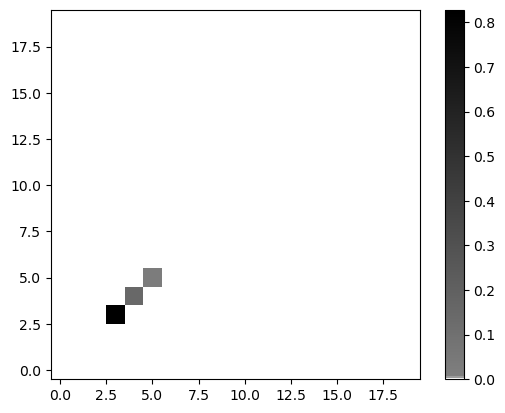

In [206]:
prob_plot = prob[50][63, :].reshape(20, 20, order='F')
plt.imshow(prob_plot, cmap=plt.get_cmap('shifted_cm_bin_01'), origin='lower')
# plt.imshow(prob_plot, cmap=plt.get_cmap('shifted_cm_bin01'),  norm=matplotlib.colors.LogNorm(vmin=1e-8, vmax=prob_plot.max()), origin='lower')
plt.colorbar()
plt.show()

In [27]:
np.log(np.arange(9).reshape(3, 3), axis=1)

TypeError: log() got an unexpected keyword argument 'axis'

# Plot

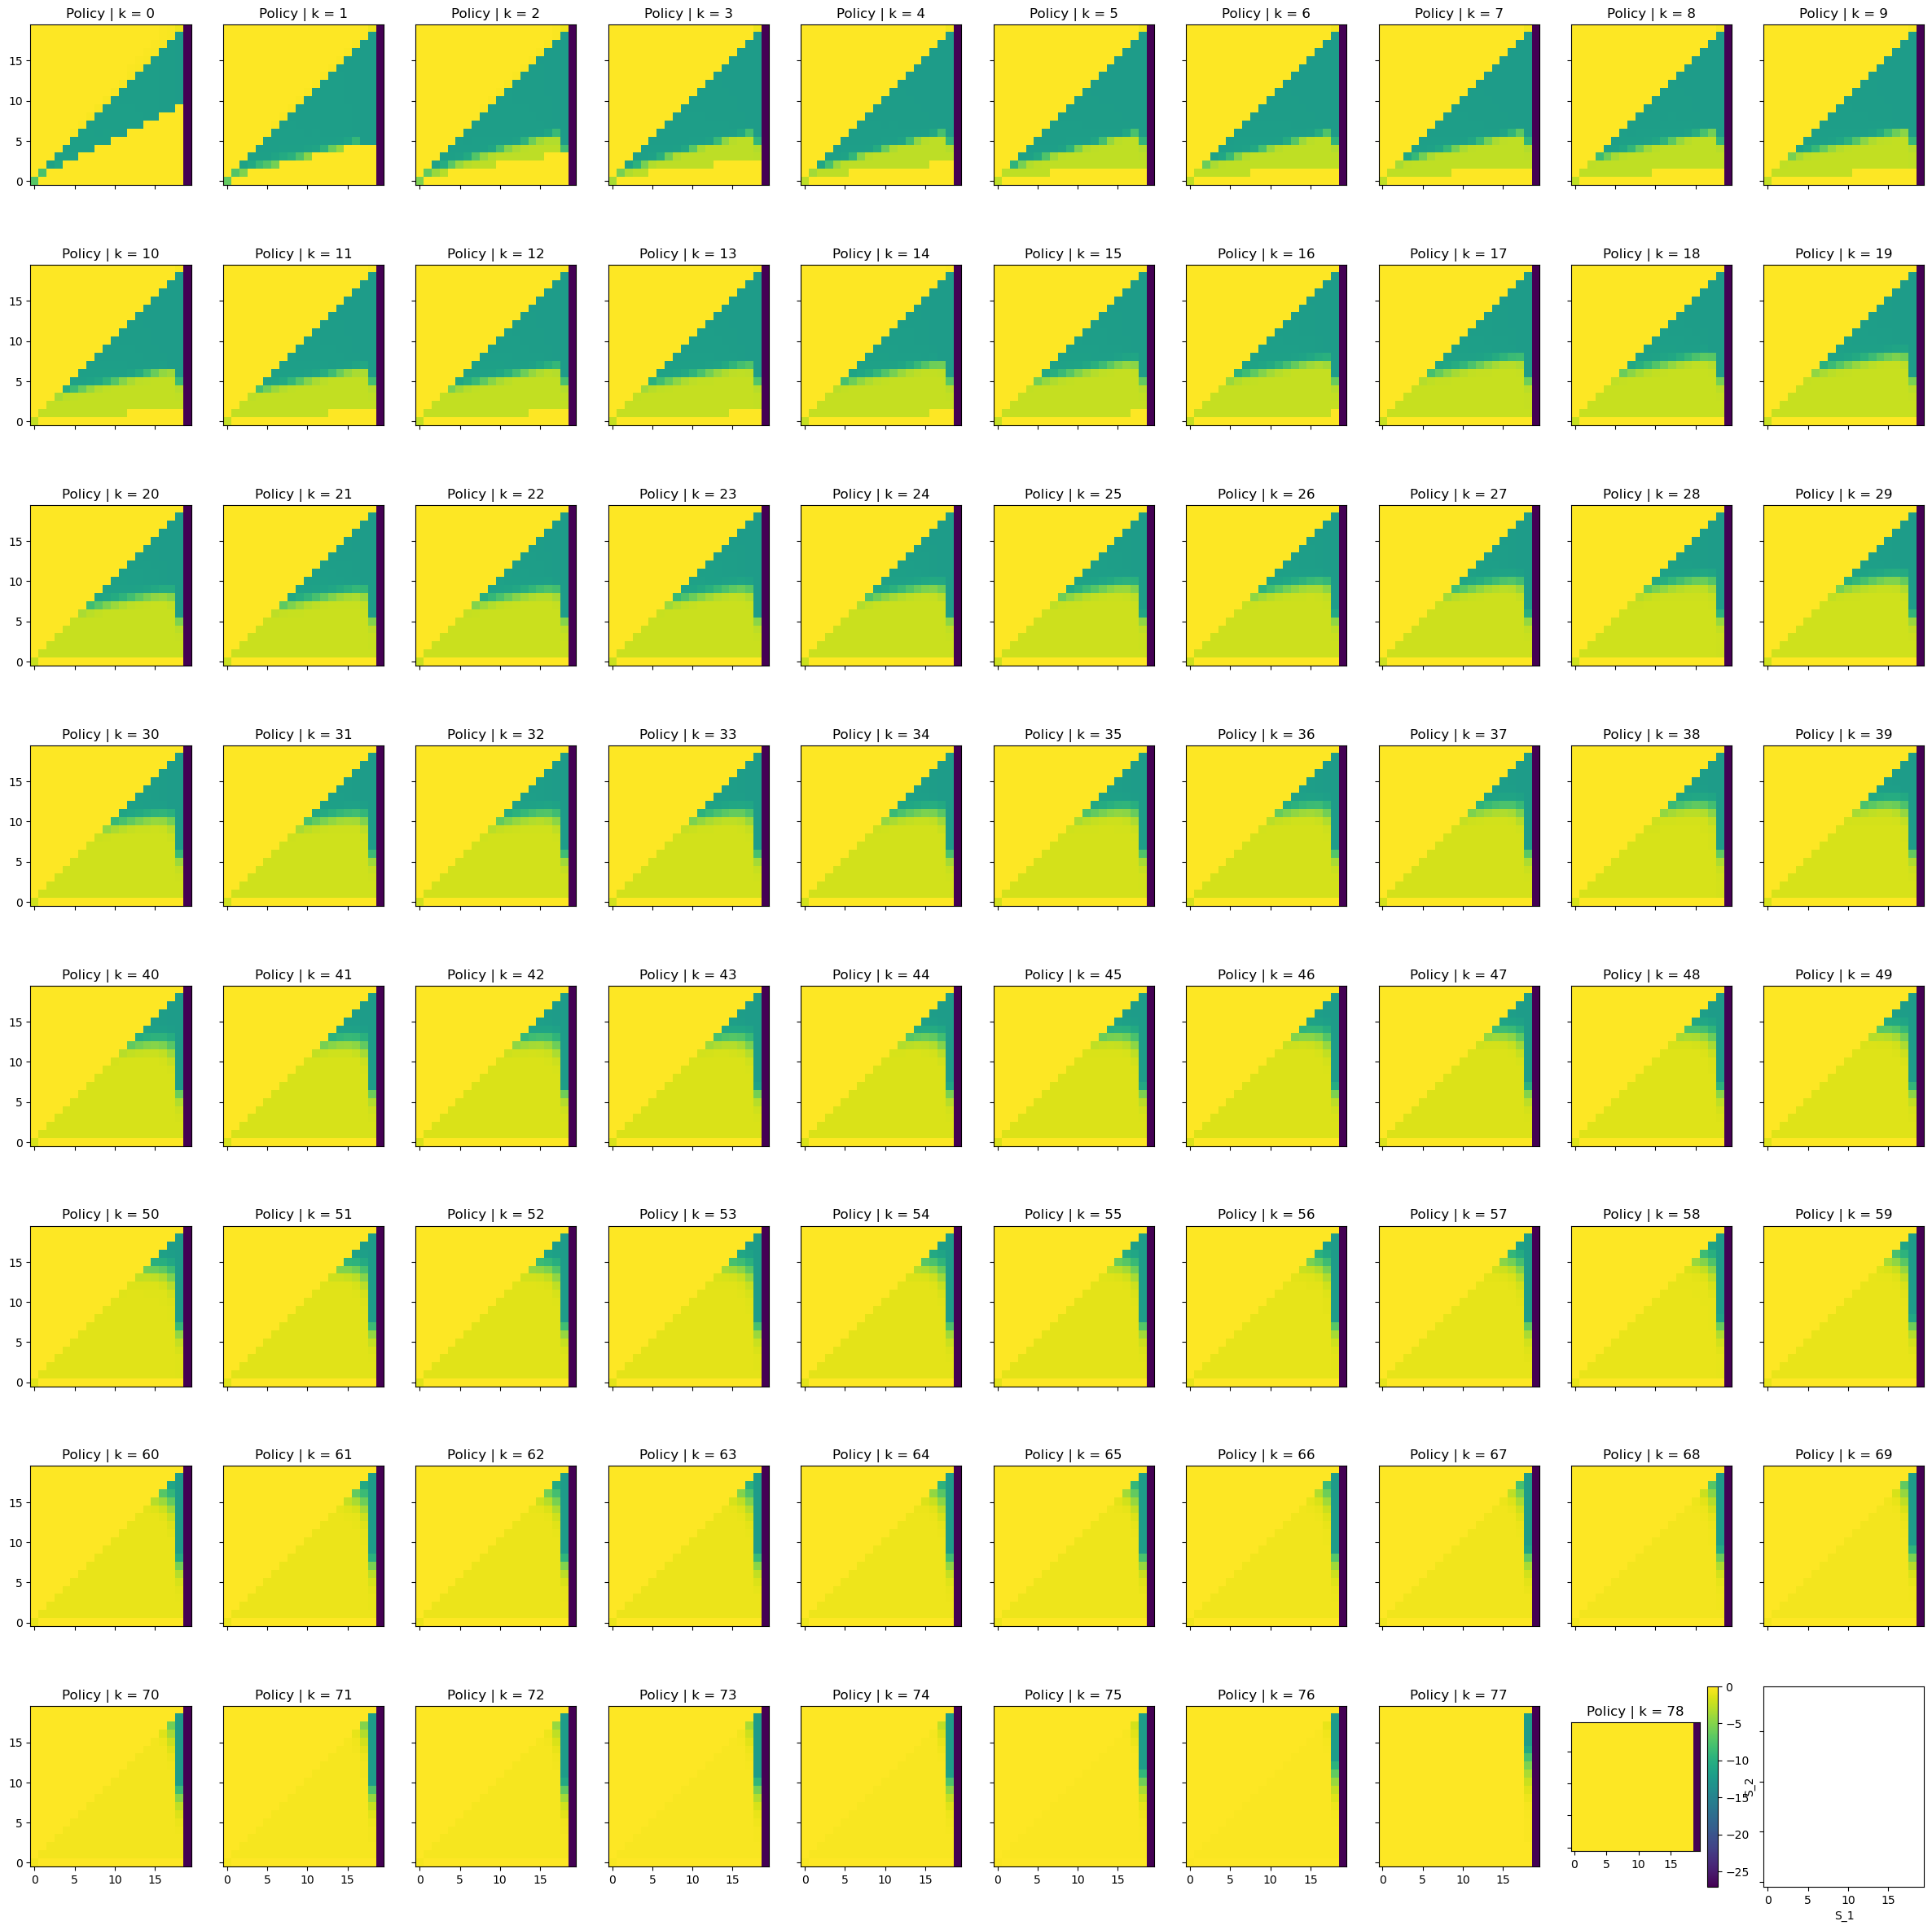

In [10]:
S = 20
K = 80
index = 3
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag_history[index][k].reshape(S, S)
    pi_2d = val_history[index][k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    im = ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')
fig.colorbar(im)

# fig.savefig('policy.svg')

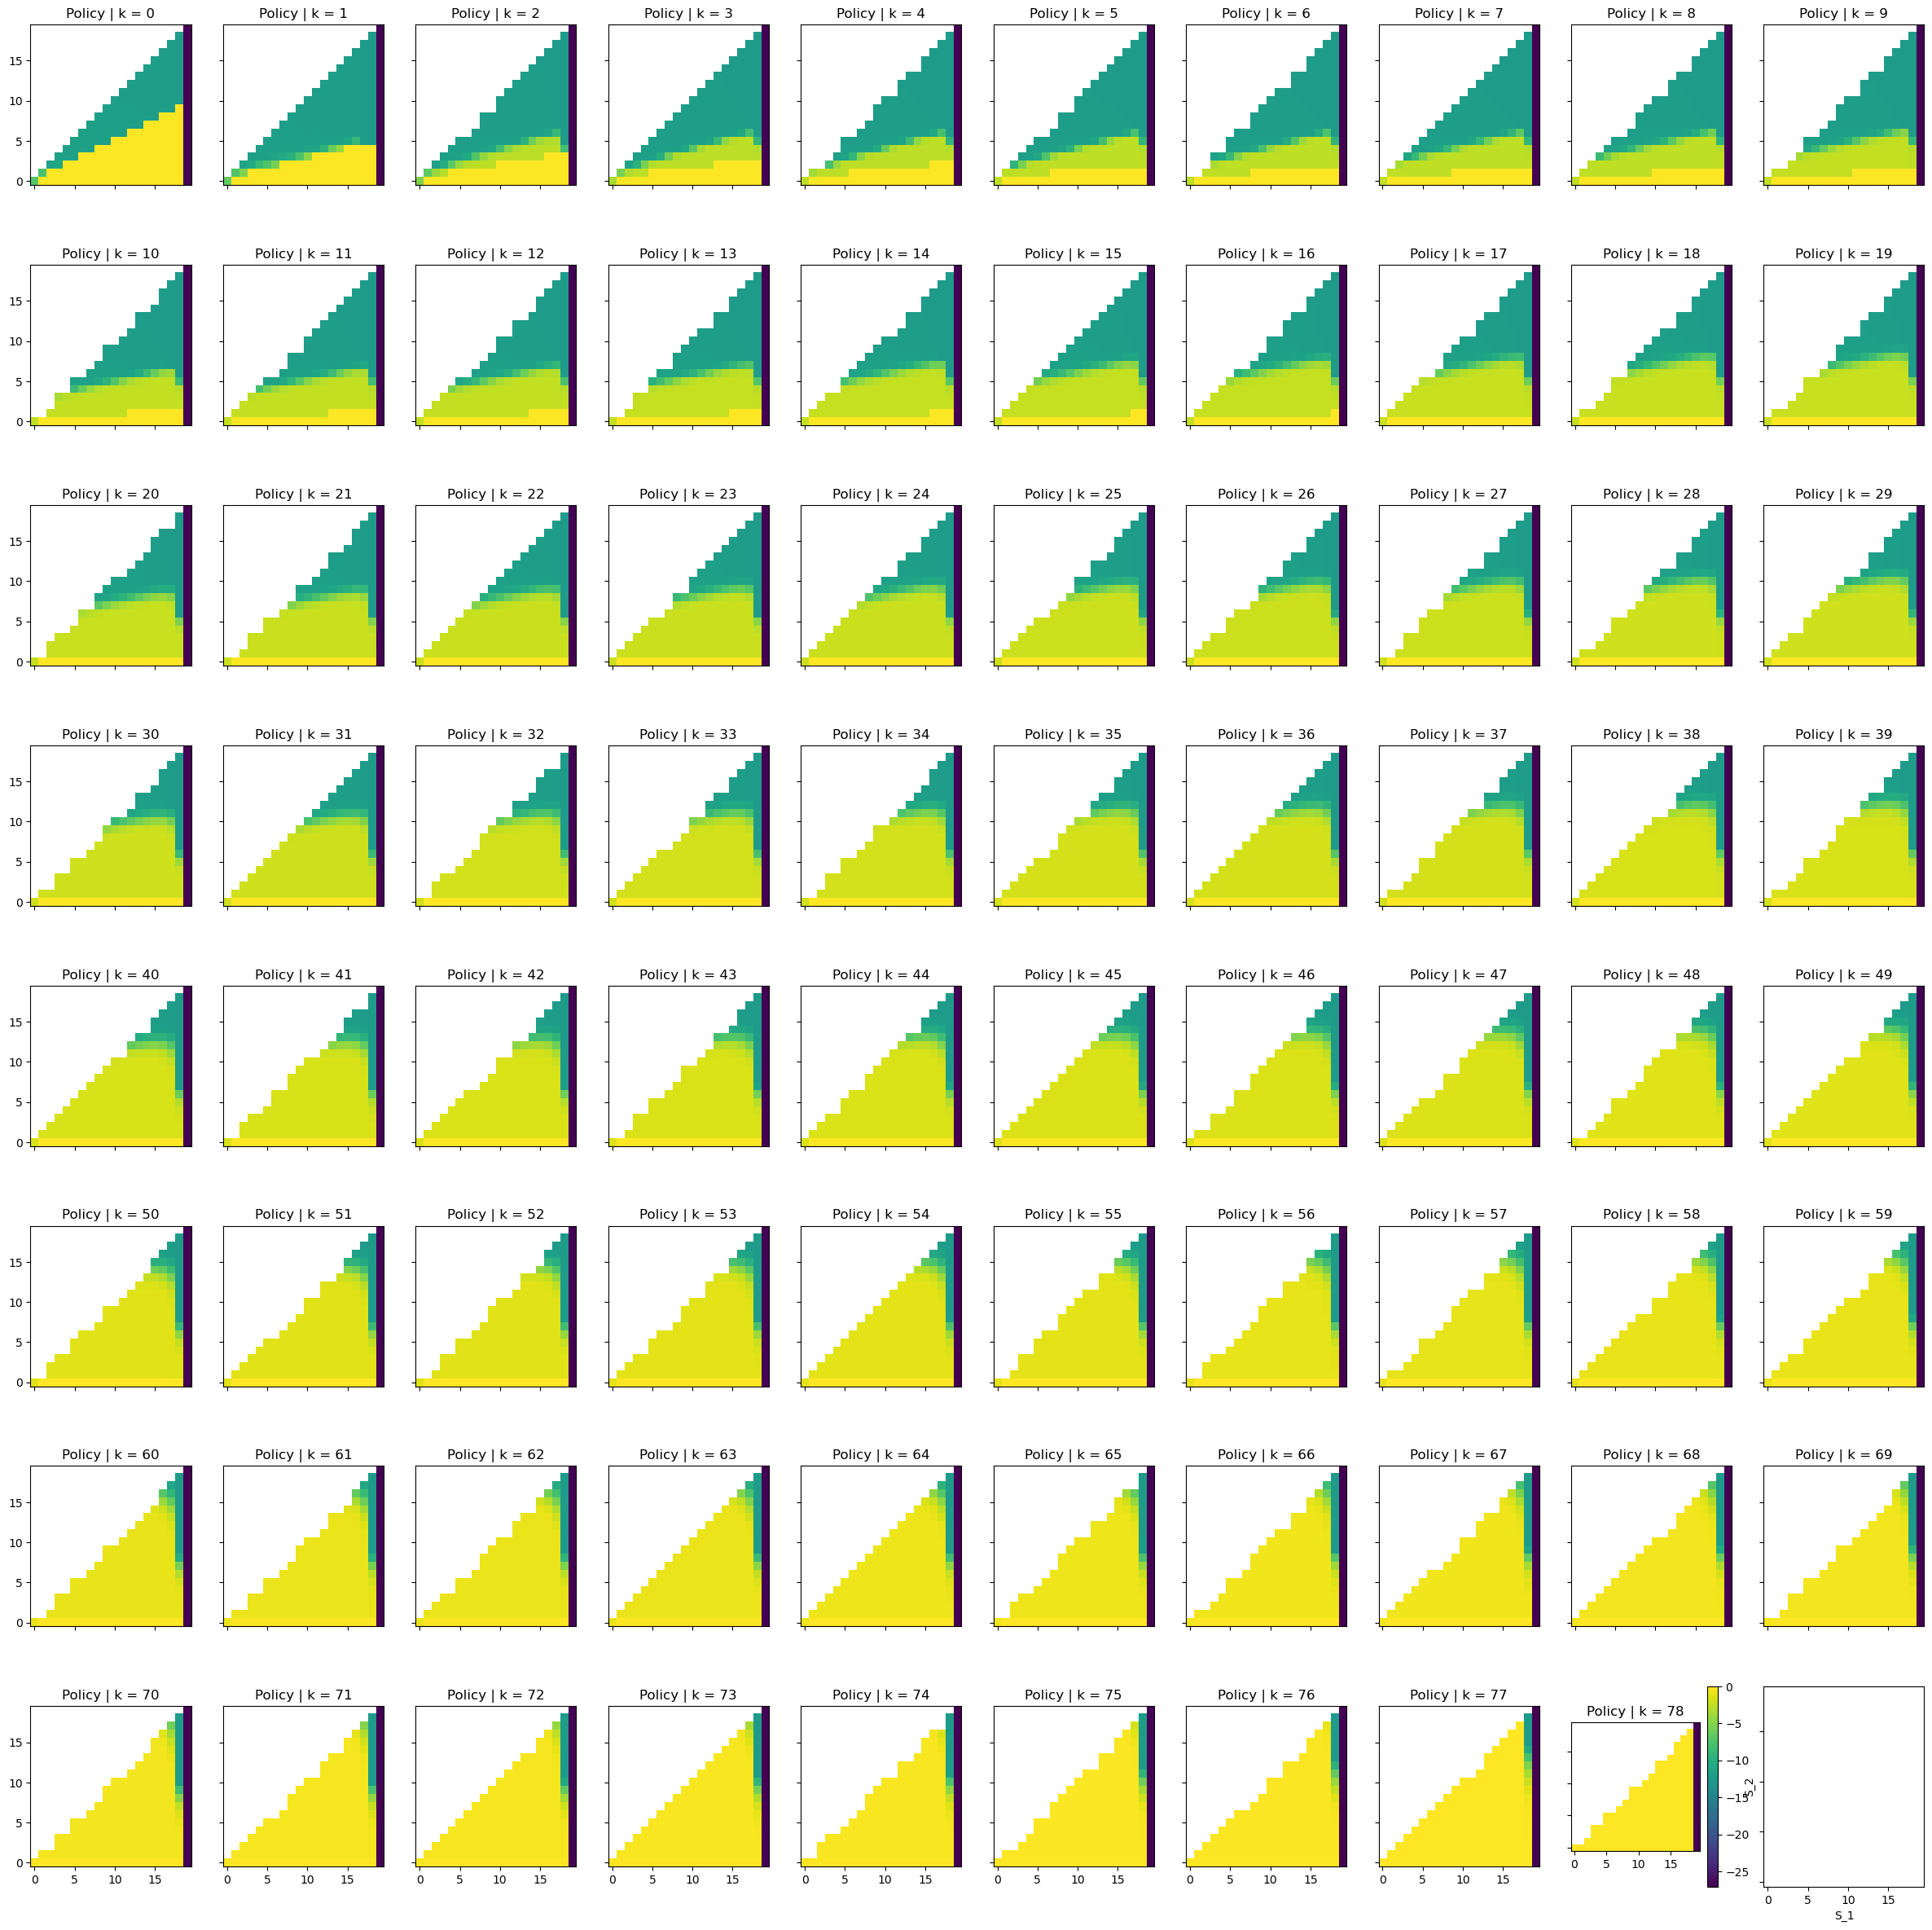

In [11]:
S = 20
K = 80
index = 3
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag_history[index][k].reshape(S, S)
    pi_2d = val_history[index][k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    im = ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')
fig.colorbar(im)

# fig.savefig('policy.svg')

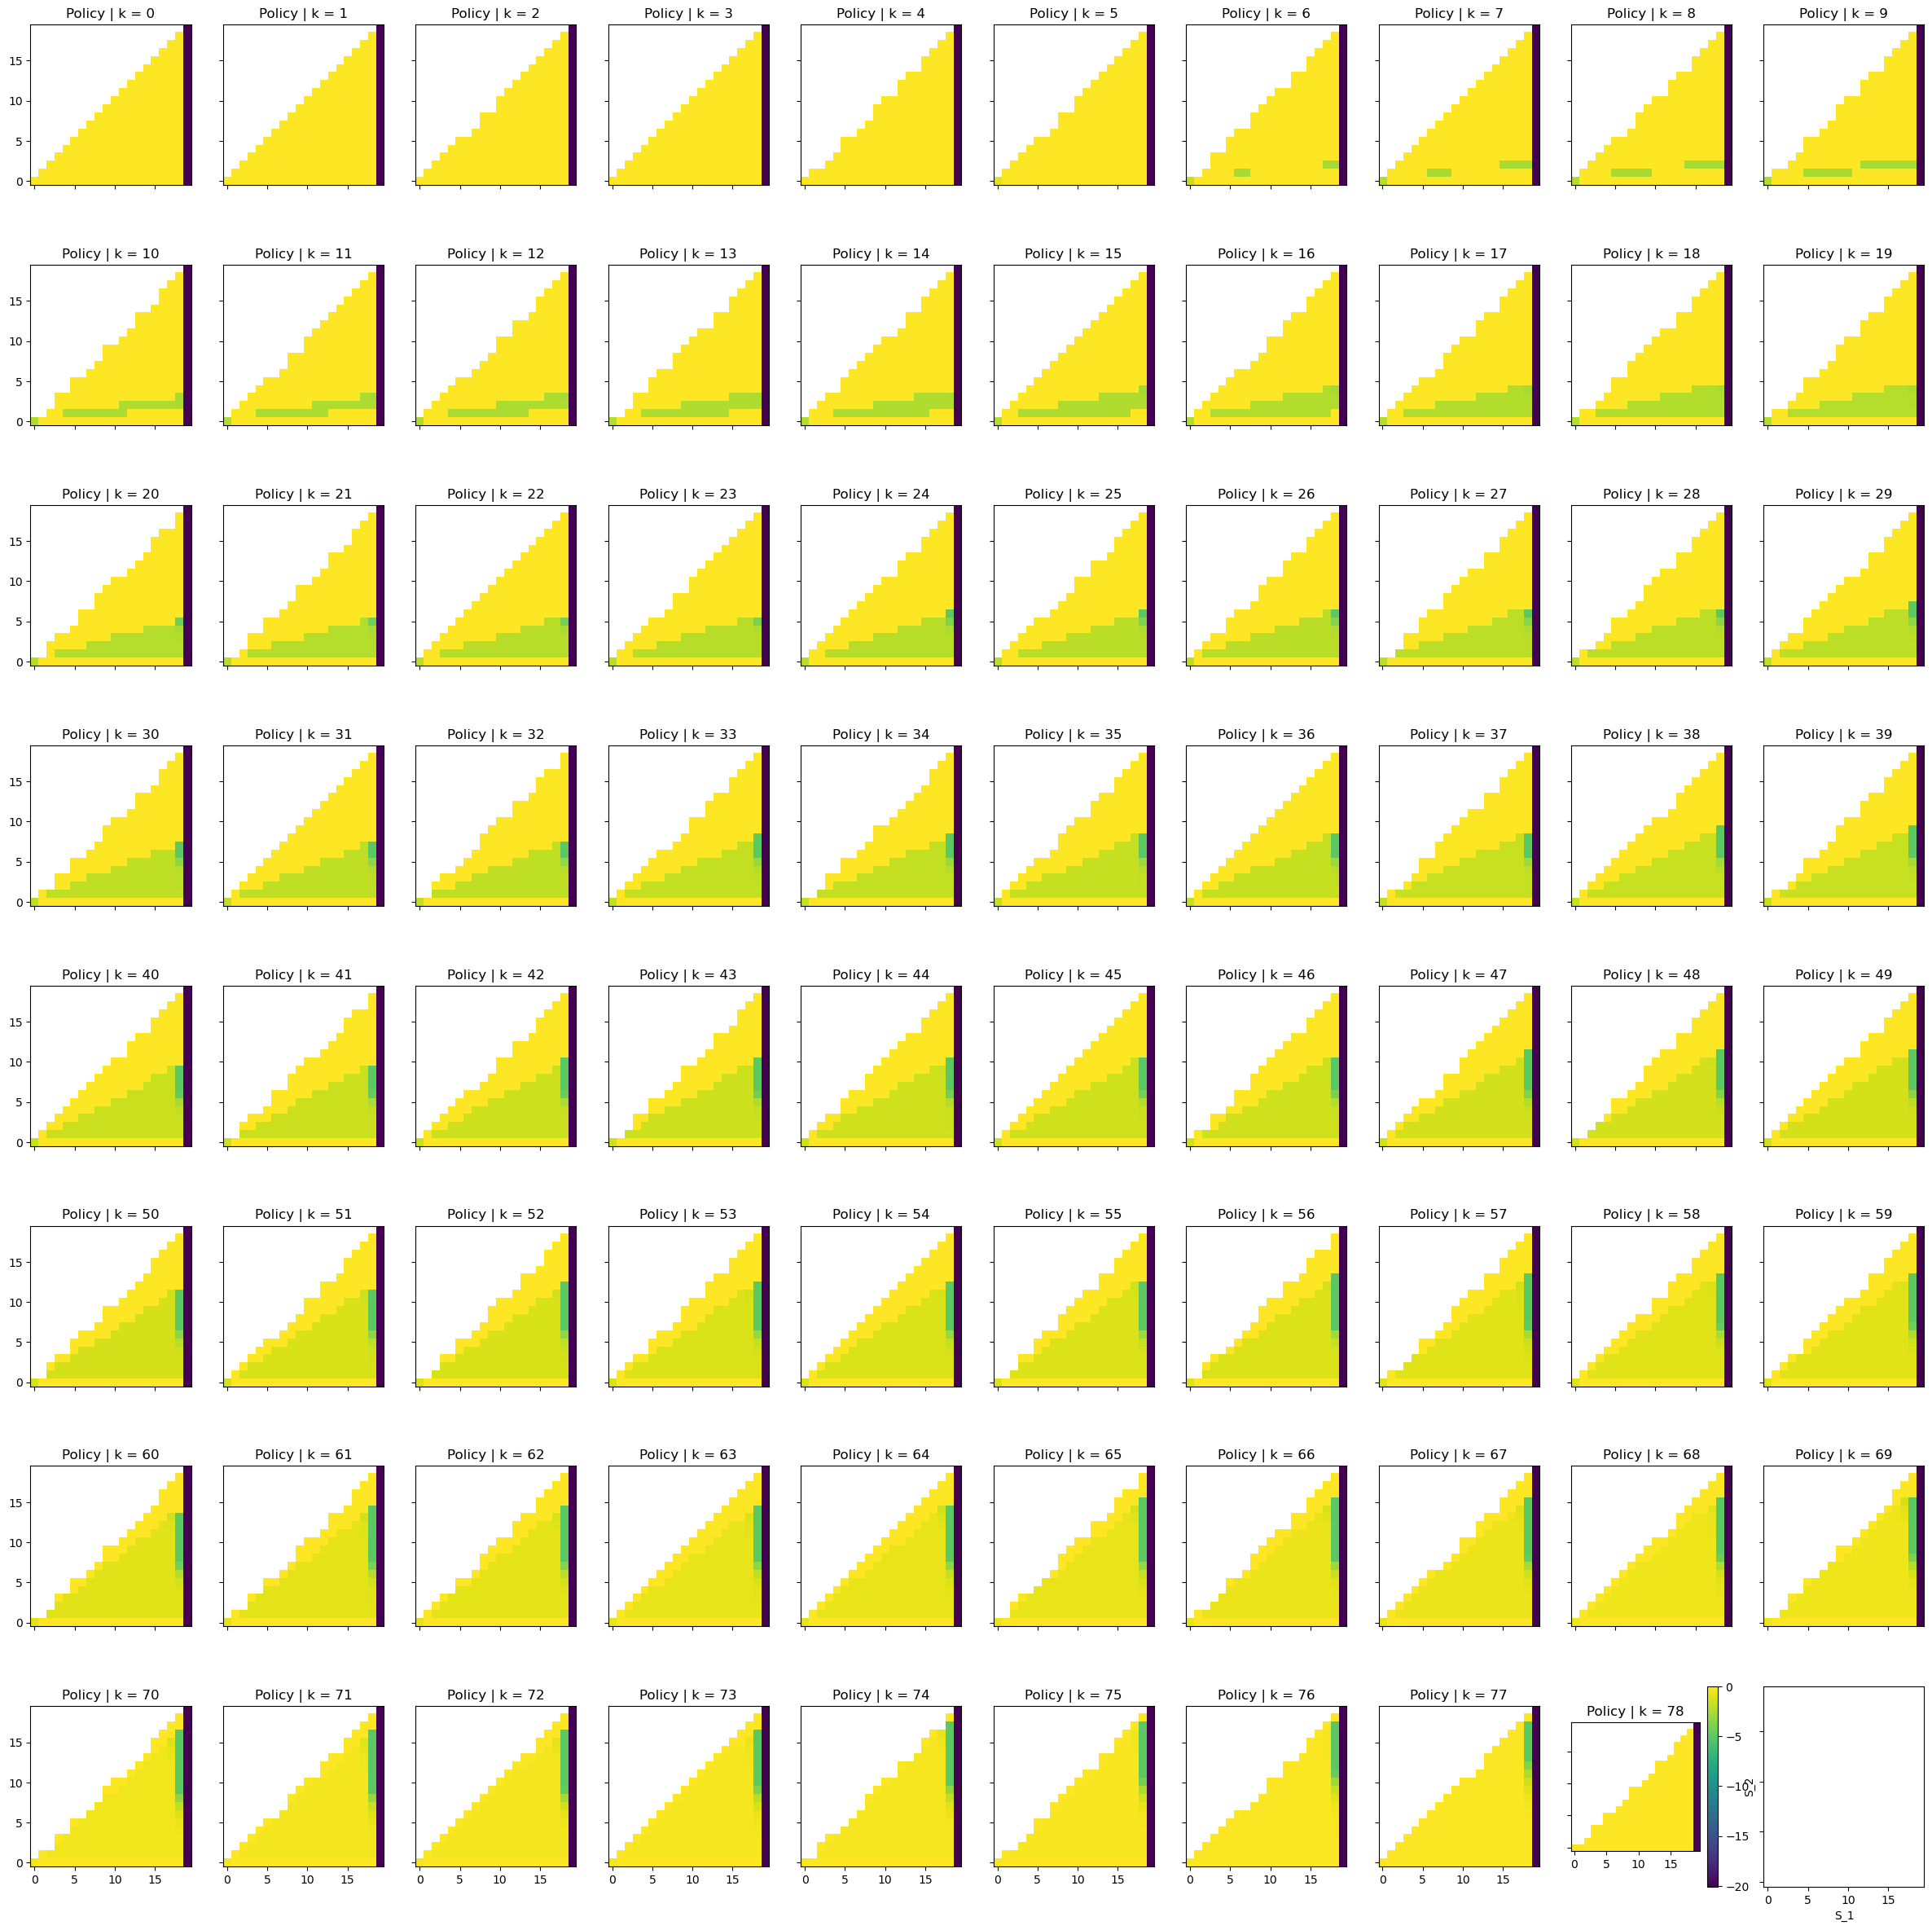

In [21]:
S = 20
K = 80
index = 3
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag_history[index][k].reshape(S, S)
    pi_2d = val_history[index][k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    im = ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')
fig.colorbar(im)

# fig.savefig('policy.svg')

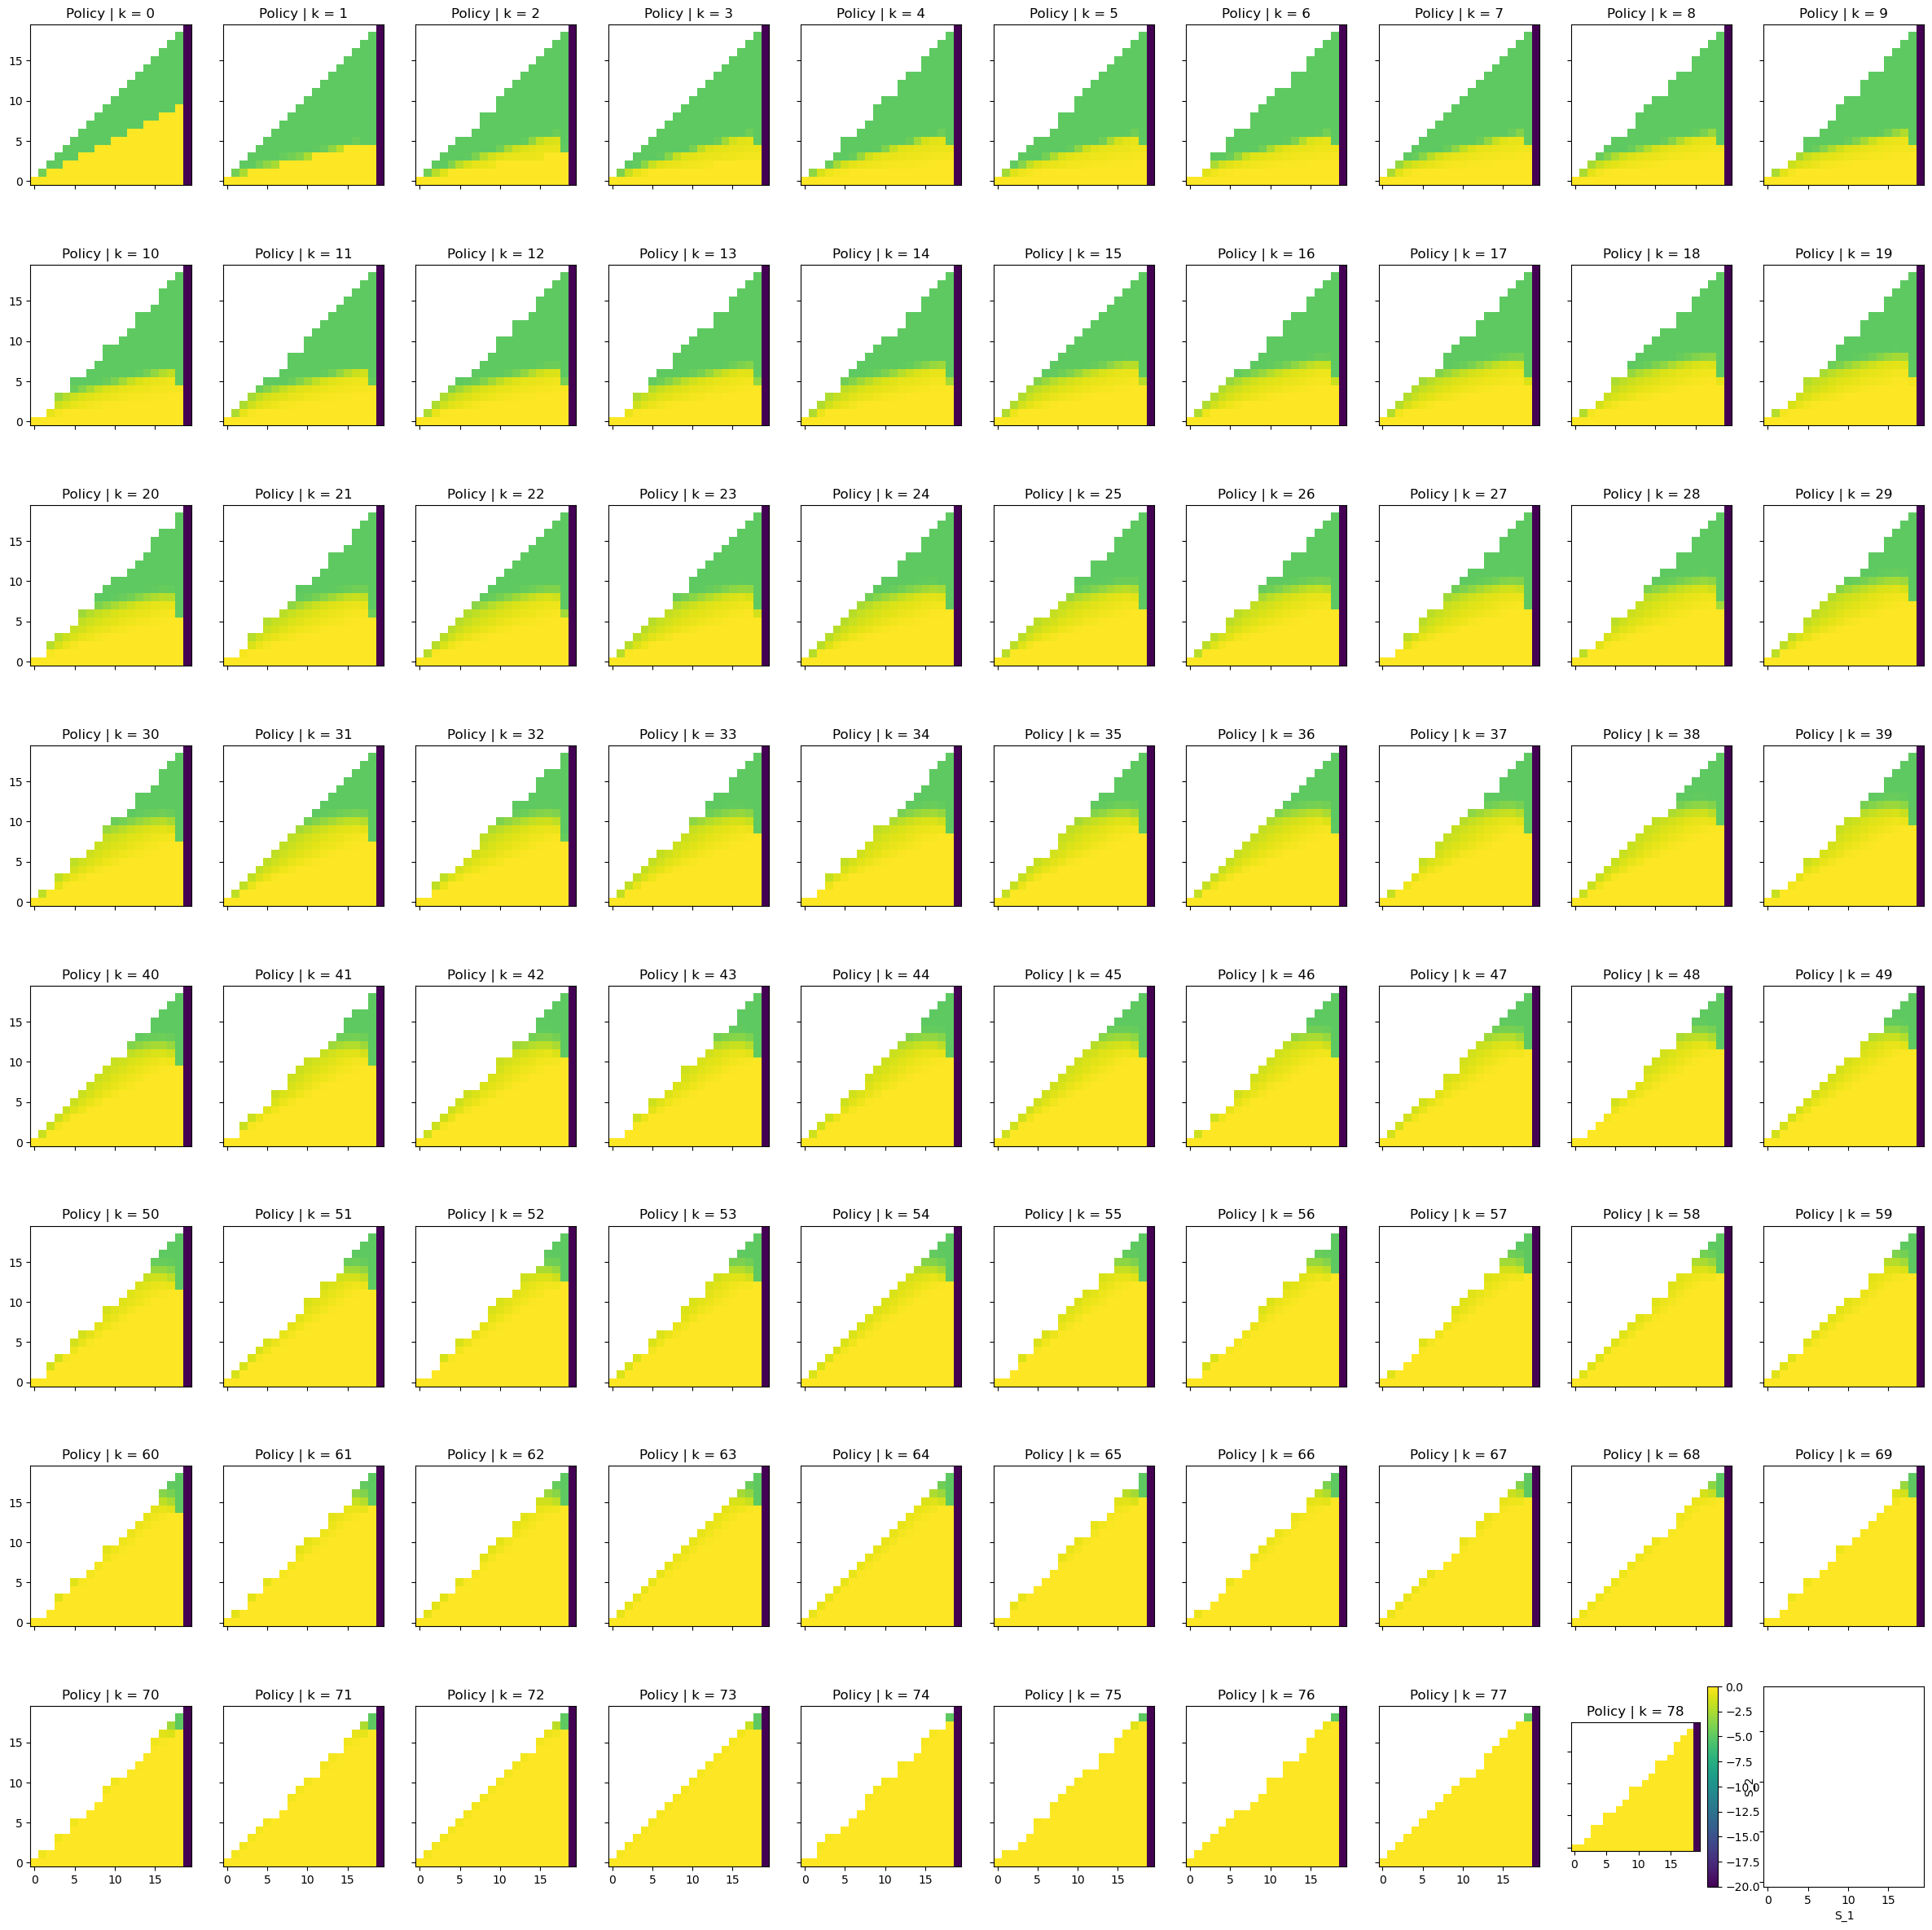

In [26]:
S = 20
K = 80
index = 3
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag_history[index][k].reshape(S, S)
    pi_2d = val_history[index][k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    im = ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')
fig.colorbar(im)

# fig.savefig('policy.svg')

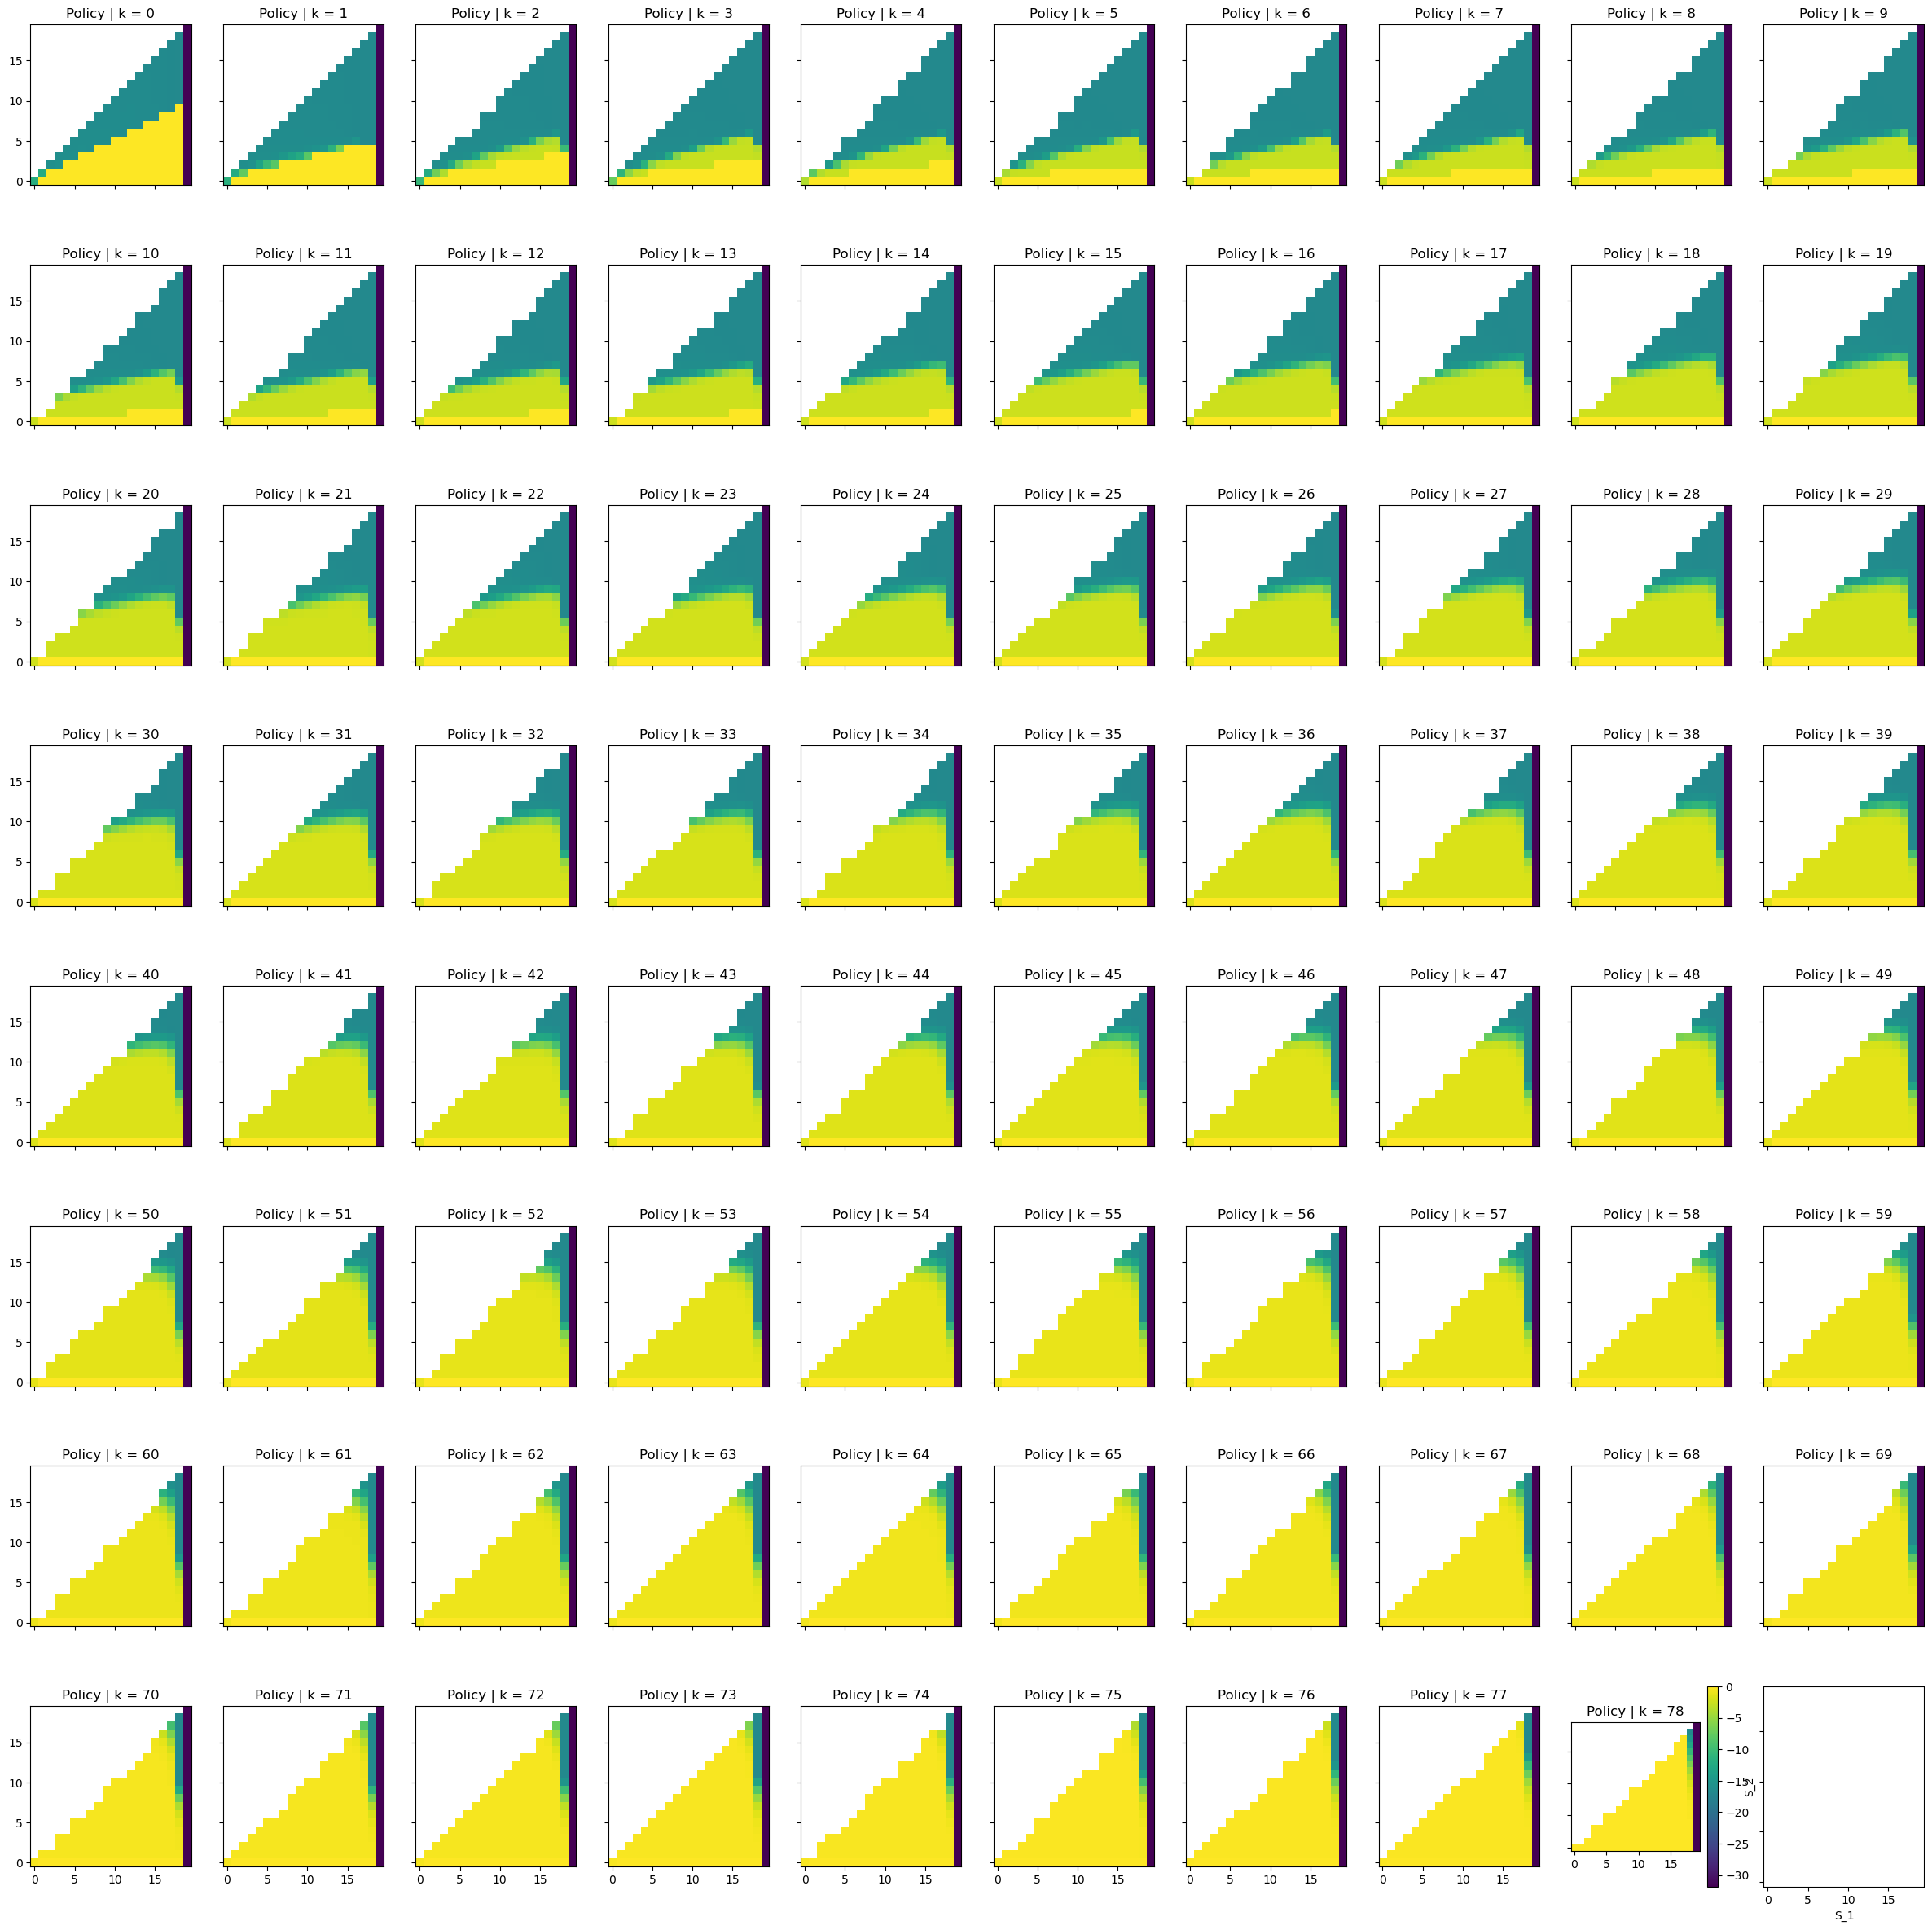

In [97]:
S = 20
K = 80
index = 3
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag_history[index][k].reshape(S, S)
    pi_2d = val_history[index][k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    im = ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')
fig.colorbar(im)

# fig.savefig('policy.svg')

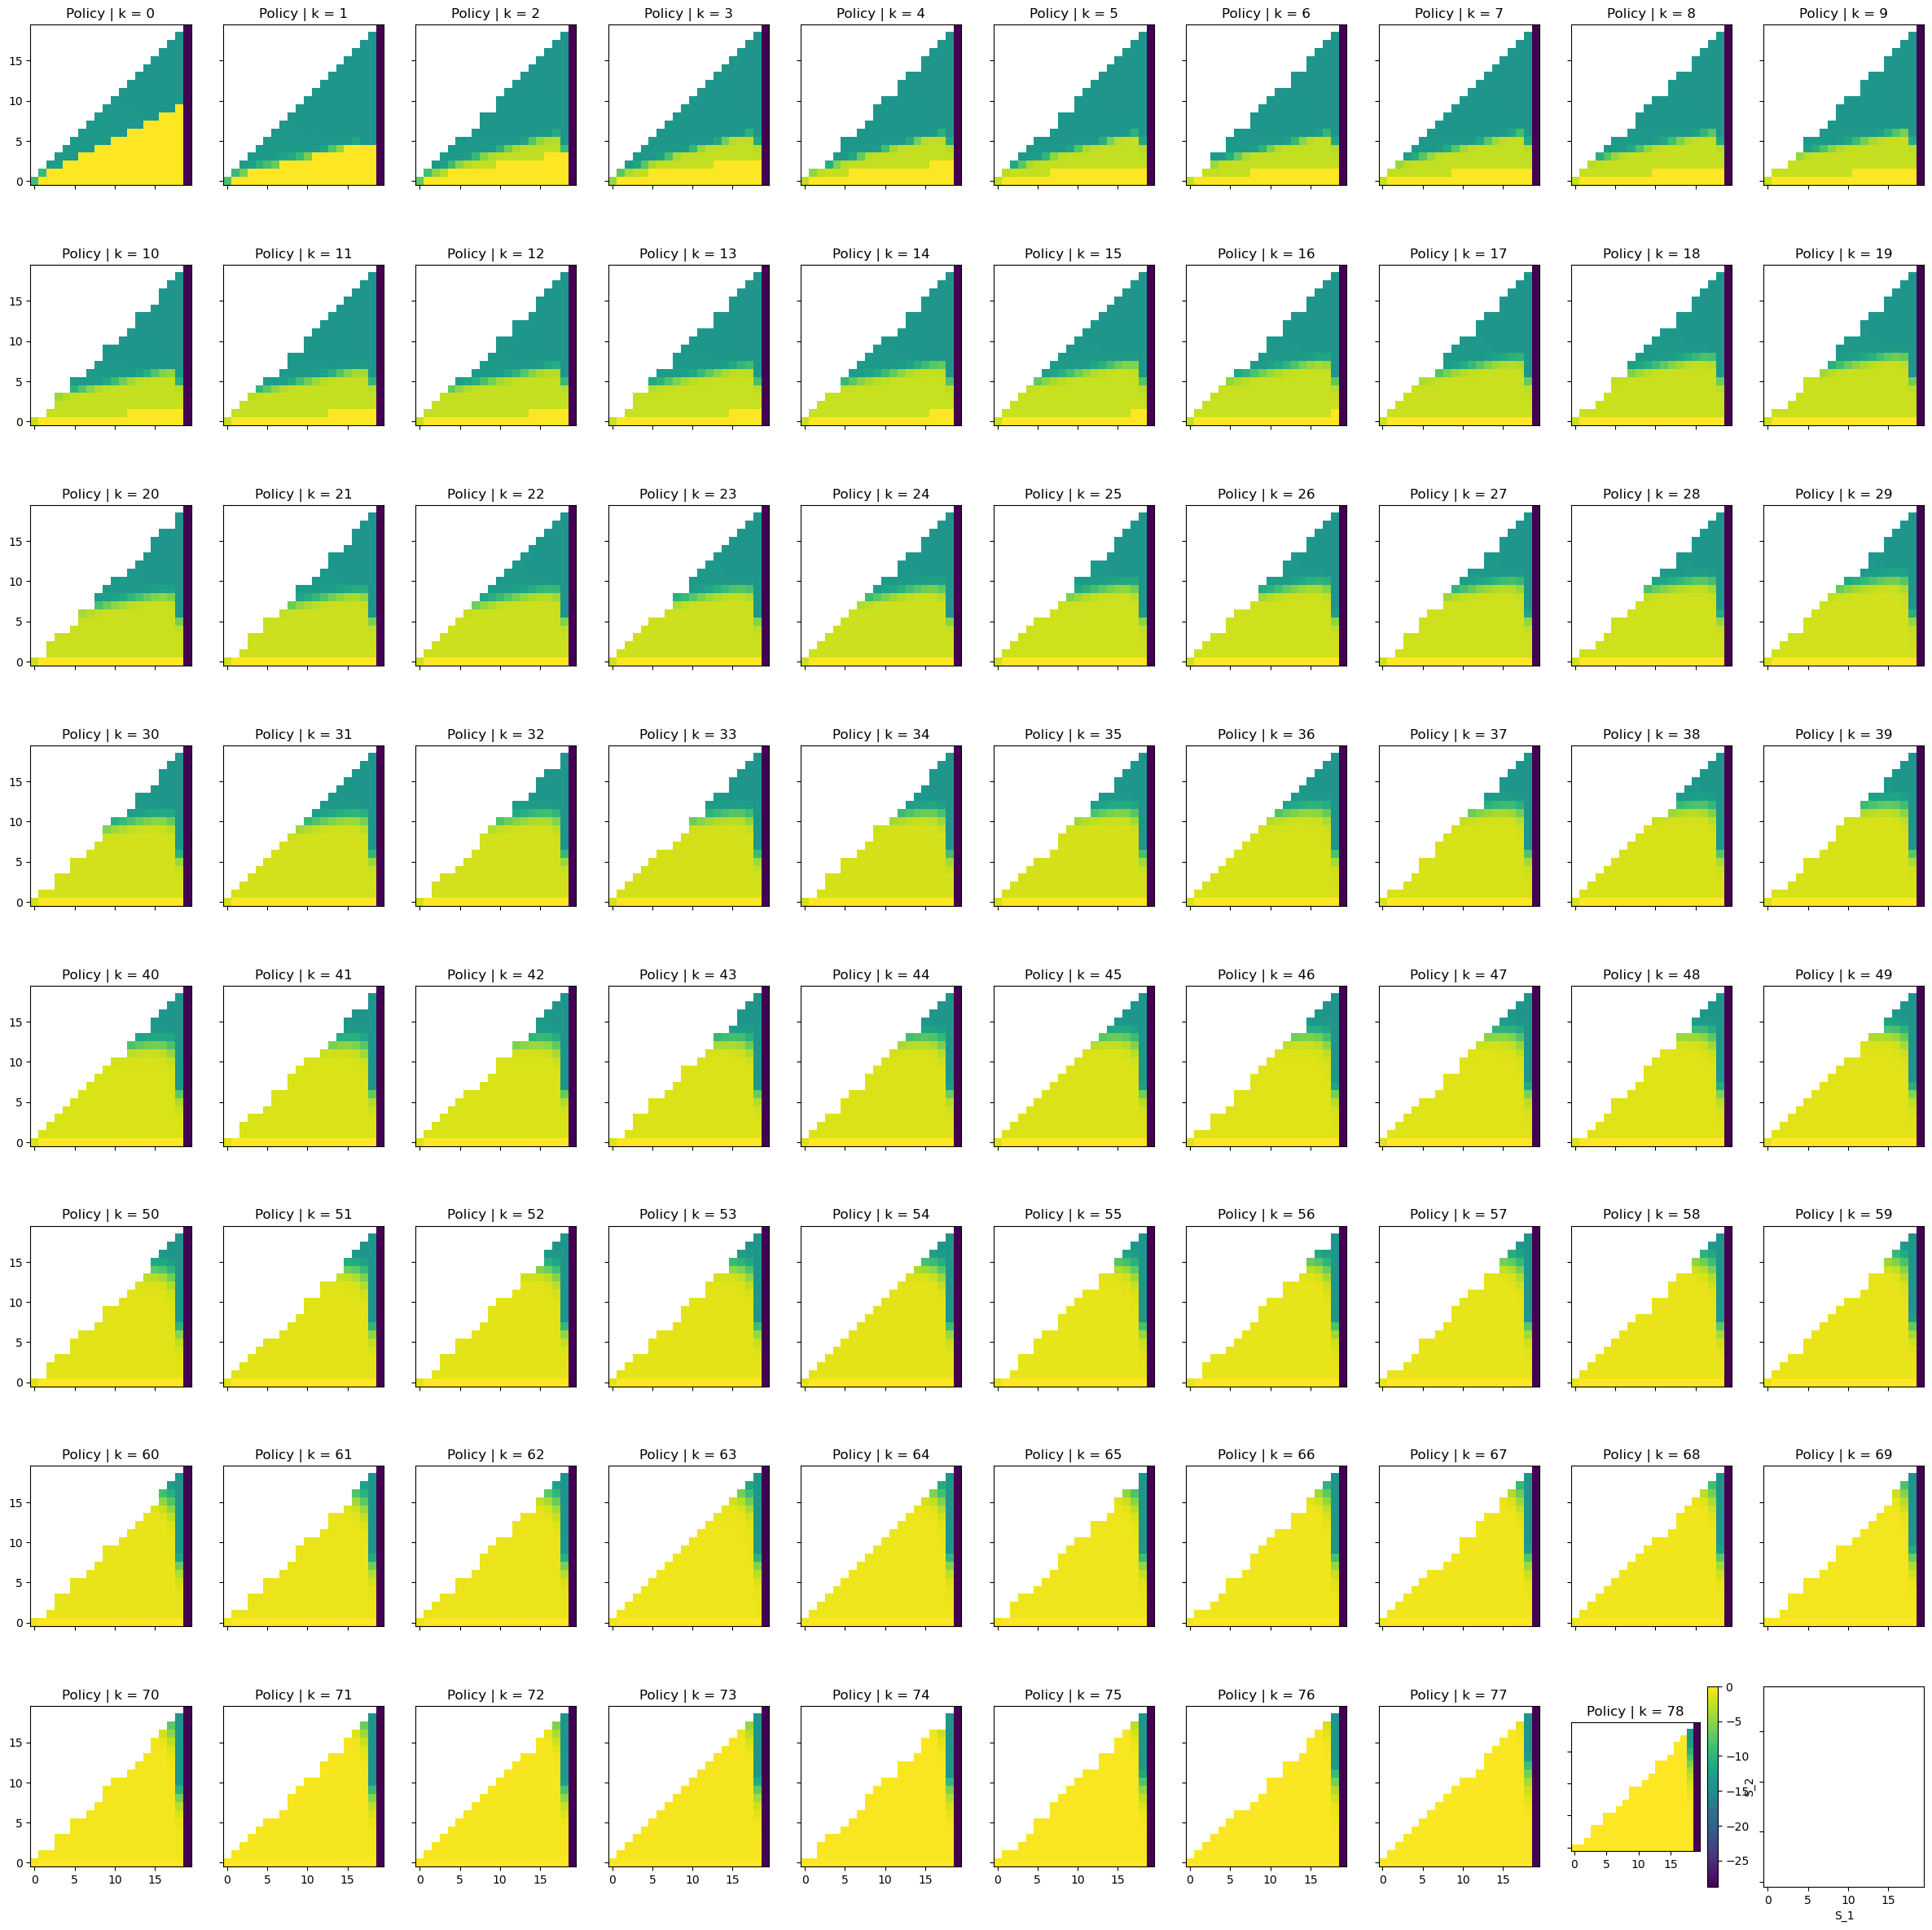

In [113]:
S = 20
K = 80
index = 3
fig, ax = plt.subplots(8, 10, figsize=(30, 30), sharex=True, sharey=True)
for k in range(K-1):
    flag_2d = flag_history[index][k].reshape(S, S)
    pi_2d = val_history[index][k].reshape(S, S)
    
    flag_pi_2d = np.ma.array(pi_2d, mask=~flag_2d)
    
    # Plot
    im = ax[k//10, k%10].imshow(np.transpose(flag_pi_2d), cmap='viridis', origin='lower')
    ax[k//10, k%10].set_title(f"Policy | k = {k}")
plt.xlabel('S_1')
plt.ylabel('S_2')
fig.colorbar(im)

# fig.savefig('policy.svg')

- When to update?
- Structure
1. Linear


## Note
- $t_{k+1}^\top A_k$ can be calculated only once and does not depend on $S_k$

# Recycle bin

In [ ]:
def calc_one_step_transition_prob(s_k_index, mean, std, s_k, v_array, h_array, new_bins, args):
    # Declare variable
    print(f"At state {s_k_index} ({s_k})")
    print(f"mean = {mean} | std = {std}")

    v_counter = s_k_index[0]; h_counter = s_k_index[1];
    ss_1, ss_2 = new_bins
    prob = np.zeros((args['S'], args['S']))
    curr_ss1 = s_k[0]; curr_ss2 = s_k[1]
    intersection_list = [s_k]

    while curr_ss1 < args['s1_limit'] and curr_ss2 < args['s2_limit']:
        next_v_xaxis = v_array[v_counter+1, 0]
        next_h_xaxis = h_array[h_counter+1, 0]
        if np.abs(next_h_xaxis - next_v_xaxis) <= args['epsilon']:
            end_point = v_array[v_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter + 1
            new_h_counter = h_counter + 1
            
        elif next_v_xaxis > next_h_xaxis:
            end_point = h_array[h_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter
            new_h_counter = h_counter + 1
            
        elif next_v_xaxis < next_h_xaxis:
            end_point = v_array[v_counter+1, :]
            starting_point = intersection_list[-1]
            
            new_v_counter = v_counter + 1
            new_h_counter = h_counter

        # Update posterior for current state at (v_counter, h_counter)
        # Transform end_point and starting_point into x_1 and x_2
        x_1 = (starting_point[0] - s_k[0]) / args['delta']
        x_2 = (end_point[0] - s_k[0]) / args['delta']
        
        # Normalize x_1 and x_2
        z_1 = (x_1 - mean) / std
        z_2 = (x_2 - mean) / std
        
        # Find standard normal CDF of x_1 and x_2
        F_1 = scipy.stats.norm.cdf(z_1)
        F_2 = scipy.stats.norm.cdf(z_2)

        transition_prob = F_2 if (starting_point == s_k).all() else F_2 - F_1
        prob[v_counter, h_counter] = transition_prob
        print(f"transition to state {(v_counter, h_counter)} | transition prob. = {transition_prob}")
        
        # Update the list of interesecting points
        intersection_list.append(end_point)
        curr_ss1 = end_point[0]; curr_ss2 = end_point[1]
        
        # Update v_counter and h_counter
        v_counter_old = v_counter; v_counter = new_v_counter;
        h_counter_old = h_counter; h_counter = new_h_counter;

    intersection_list = np.stack(intersection_list)
    prob[v_counter, h_counter] = 1 - np.sum(prob)
    print(f"transition to state {(v_counter, h_counter)} | transition prob. = {prob[v_counter, h_counter]}")
    print('-------------------------')
    
    # Reshape prob
    prob = prob.flatten()
    return prob

def calc_transition_prob(state_partition, new_bins, bins, prior_mean, prior_cov, args):
    # Declare variables
    sigma0 = args['sigma0']
    extended_state_space = args['S'] ** 2
    ss_1, ss_2 = new_bins
    
    # Inverse covaraince
    inv_prior_cov = np.linalg.inv(prior_cov)

    # Matrix of K x S x S
    prob = np.zeros((args['K'], extended_state_space, extended_state_space))
    for k in range(args['K']-1):
        for s in range(extended_state_space):
            # Retrieve state index
            state_index = (s // args['S'], s % args['S'])
            s_k = state_partition[s]
            
            # Calculate the state limit
            upper_limit_slope = args['delta'] * (k+1.01)
            lower_limit_slope = args['delta']
            state_cond_upper = upper_limit_slope * s_k[0]
            state_cond_lower = lower_limit_slope * s_k[0]
            # Update posterior distribution by approximated lk if k > 0

            if k > 0 and (s_k[1] <= state_cond_upper and s_k[1] >= state_cond_lower):
                if s  == 50:
                    break
                
                # Calculate t_k and t_{k+1}
                delta_poly = (args['delta'] ** np.arange(1, 3)).reshape(-1, 1)
                
                tk = np.multiply(delta_poly, np.array([[1], [k]])); tk_plus1 =  np.multiply(delta_poly, np.array([[1], [k+1]]))
                tk_list = np.vstack((np.repeat(1, k), np.arange(1, k+1)))
                
                T_list = np.multiply(delta_poly, tk_list)
                
                # Calculate A_k and b_k which are components in our posterior
                A_k = np.linalg.inv((1/sigma0**2) * (T_list @ T_list.T) + inv_prior_cov)
                b_k = (1/sigma0**2) * s_k.reshape(-1, 1) + inv_prior_cov @ prior_mean

                # Posterior mean and sigma
                mu_k = (tk_plus1.T @ A_k @ b_k).item()
                sigma_k = np.sqrt(sigma0**2 + tk_plus1.T @ A_k @ tk_plus1).item()

                # p1 is the current state and p2 is the mean of predictive distribution
                p1 = s_k
                p2 = (s_k[0] + mu_k * tk_plus1[0, 0], s_k[1] + mu_k * tk_plus1[1, 0])
                
                # Calculate slope
                m = tk_plus1[1, 0] / tk_plus1[0, 0]
                b = p2[1] - m * p2[0]
                
                # Calculate the intersection with the grid
                v_intersection = m * ss_1 + b
                h_intersection = (1/m) * (ss_2 - b)
                v_array = np.vstack((ss_1, v_intersection)).T
                h_array = np.vstack((h_intersection, ss_2)).T

                # Plot
                fig, ax = plt.subplots(figsize=(15, 15))
                ax.scatter(bins[:, 0], bins[:, 1], s=10, c='r', marker='x')
                ax.scatter(state_partition[:, 0], state_partition[:, 1], s=10)
                ax.axline([0, 0], slope=upper_limit_slope, color='gold')
                ax.axline([0, 0], slope=lower_limit_slope, color='darkorange')
                ax.set_xlim([-1, args['s1_limit'] * 1.05])
                ax.set_ylim([-15, args['s2_limit'] * 1.05])
                ax.grid(visible=True, alpha=0.1)

                ax.scatter(ss_1, v_intersection, marker='v', c='orange', s=15)
                ax.scatter(h_intersection, ss_2, marker='^', c='black', s=20)
                ax.axline(p1, slope=m, color='g')
                ax.plot(p2[0], p2[1], marker='o', color='g')
                ax.plot(s_k[0], s_k[1], marker='x', color='black', markersize=20)
                ax.set_xticks(bins[:, 0])
                ax.set_yticks(bins[:, 1])
                ax.set_xlabel('S_1')
                ax.set_ylabel('S_2')

                prob[k, s, :] = calc_one_step_transition_prob(state_index, mu_k, sigma_k, s_k, v_array, h_array, new_bins, args)
            else:
                mu_k = prior_mean
                sigma_k = prior_cov
        
#     return prob

In [ ]:
#                 if k == 50:
#                     fig, ax = plt.subplots(figsize=(15, 15))
#                     ax.scatter(bins[k][:, 0], bins[k][:, 1], s=10, c='r', marker='x')
#                     ax.scatter(state_partition[k][:, 0], state_partition[k][:, 1], s=10)
#                     ax.axline([0, 0], slope=upper_limit_slope, color='gold')
#                     ax.axline([0, 0], slope=lower_limit_slope, color='darkorange')
#                     ax.set_xlim([-1, args['s1_limit'] * 1.05])
#                     ax.set_ylim([-1, args['s1_limit'] * (k+1) * 1.05])
#                     ax.grid(visible=True, alpha=0.1)

#                     ax.scatter(ss_1, v_intersection, marker='v', c='orange', s=15)
#                     ax.scatter(h_intersection, ss_2, marker='^', c='black', s=20)
#                     ax.axline(s_k, slope=m, color='g')
#                     ax.plot(p2[0], p2[1], marker='o', color='g')
#                     ax.plot(s_k[0], s_k[1], marker='x', color='black', markersize=20)
#                     ax.set_xticks(bins[k][:, 0])
#                     ax.set_yticks(bins[k][:, 1])
#                     ax.set_xlabel('S_1')
#                     ax.set_ylabel('S_2')

In [ ]:
                # Plot after
#                 color_mapping = prob[k, s, :] + 0.1
#                 color_mapping = color_mapping / np.sum(color_mapping)
#                 fig, ax = plt.subplots(figsize=(15, 15))
#                 ax.scatter(state_partition[:, 0], state_partition[:, 1], s=10, alpha=color_mapping)
                
#                 ax.set_xticks(bins[:, 0])
#                 ax.set_yticks(bins[:, 1])
#                 ax.set_xlabel('S_1')
#                 ax.set_ylabel('S_2')
#                 ax.grid(visible=True, alpha=0.05)

In [ ]:
    for i in range(args['max_iter']):
        old_value = copy.deepcopy(value)
#         print(value[0, :].reshape(args['S'], args['S']))
        for k in range(args['K']-2):
            for s in range(S_square):
                # At state (k, s)
                # Check edge case
                start_inner = time.time()
                lk = new_bins_2d[k][s, 0]
                if lk > args['r_limit']:
                    value[k, s] = c1 + gamma * value[0, 0]
                    pi[k, s] = 1
                    continue

                # Two possible actions: replace and not replace
                # Calculate transition probability
                curr_prob = prob[k, s]
                future_cost = gamma * value[k+1, :]

                # Evaluate value of current state
                cost_A0 = np.dot(curr_prob, c3 + future_cost) # Not replacing machine           
                cost_A1 = c2 + gamma * value[0, 0] # Replacing machine
                
#                 print(f"k = {k} | state {new_bins_2d[s]} | A0 = {cost_A0} | A1 = {cost_A1}")
                value[k, s] = np.max([cost_A0, cost_A1])
                pi[k, s] = int(cost_A0 < cost_A1)
                inner_time.append(time.time()-start_inner)
            
#         if i % 200 == 0:
#         print(f"Iter {i+1}: gap = {np.linalg.norm(old_value - value)}")
        if np.linalg.norm(old_value - value) < args['threshold']:
            converge = 1
            break 
    if converge == 0:
        print("Reach maximum iteration before convergent")

In [ ]:
@jit(nopython=True)
def run_VI(value, pi, lk_matrix, prob, c1, c2, c3, K, max_iter, r_limit, threshold, gamma):   
    value = np.ascontiguousarray(value)
    pi = np.ascontiguousarray(pi)
    lk_matrix = np.ascontiguousarray(lk_matrix)
    prob = np.ascontiguousarray(prob)
    
    for i in range(max_iter):
        old_value = np.copy(value)

        # Set value on the edge
        value[K-1] = np.where(lk_matrix[K-1] <= r_limit, c3, c1)
        pi[K-1] = np.where(lk_matrix[K-1] <= r_limit, 0, 1)

        cost_A0 = np.copy(value[:-1, :]) # Cost of "not" replacing machines (matrix K x S)
        for k in range(K-1):
            future_cost_k = c3 + gamma * value[k+1, :]
            cost_A0[k, :] = prob[k,:,:] @ future_cost_k.T
        cost_A1 = c2 + gamma * value[0, 0] # Cost of replacing machine (scalar)

        # Set value and pi
        value[:-1, :] = np.where(cost_A0 >= cost_A1, cost_A0, cost_A1)
        pi[:-1, :] = np.where(cost_A0 >= cost_A1, 0, 1)

        # Reset value and pi if lk exceeds threshold
        value = np.where(lk_matrix > r_limit, c1 + gamma * value[0, 0], value)
        pi = np.where(lk_matrix > r_limit, 1, pi)

    #         print(f"Iter {i+1}: gap = {np.linalg.norm(old_value - value)}")
        if np.linalg.norm(old_value - value) < threshold:
            converge = 1
            break 

    return value, pi